# Eksplorasi Analisis & Prediksi Harga Pangan Menggunakan K-Nearest Neighbors (KNN)
Notebook ini berisi alur lengkap proses analisis deret waktu (*time series*) dan pembuatan model prediksi menggunakan **K-Nearest Neighbors (KNN) Regressor** untuk data harga pangan nasional berdasarkan dataset strategis dari Bank Indonesia.

### Alur Pengerjaan:
1. **Data Loading & Cleaning**: Membaca dataset dari file JSON lokal (`dataset/commodity_history.json`), mengekstrak komoditas utama (level 1) dan sub-kategori (level 2), dan mengubah bentuk data lebar (*wide format*) menjadi bentuk panjang (*long/tidy format*).
2. **Exploratory Data Analysis (EDA)**: Menganalisis karakteristik data secara visual (tren harga harian) dan statistik deskriptif, serta melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test**.
3. **Data Preprocessing & Feature Engineering**: Imputasi linear, re-sampling daily harian, dan pembuatan fitur lag & rolling statistics serta fitur kalender.
4. **Feature Scaling & Feature Selection**: Menerapkan standarisasi skala menggunakan `StandardScaler` dan menganalisis dampak fitur kalender yang bising (*noisy calendar features*) pada algoritma berbasis jarak seperti KNN.
5. **Model Tuning & Training**: Melatih model `KNeighborsRegressor` dengan mencari nilai tetangga $K$ optimal.
6. **Model Evaluation & Comparison**: Mengevaluasi hasil prediksi menggunakan metrik (MAE, RMSE, MAPE, R2) dan membandingkannya dengan model **Random Forest Baseline**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import warnings

# Menyembunyikan warning Deprecation
warnings.filterwarnings('ignore')

# Pengaturan visualisasi
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Data Collecting & Loading
Kami membaca data histori dari file lokal `dataset/commodity_history.json` yang berisi rekaman harga harian untuk 10 kategori bahan pokok berikut:
- Beras
- Daging Ayam
- Daging Sapi
- Telur Ayam
- Bawang Merah
- Bawang Putih
- Cabai Merah
- Cabai Rawit
- Minyak Goreng
- Gula Pasir

Rentang waktu yang digunakan mencakup data histori dari awal tahun 2024 hingga Mei 2026.

In [2]:
# Memuat data dari file JSON lokal atau cache CSV
categories = {
    "cat_1": "Beras",
    "cat_2": "Daging Ayam",
    "cat_3": "Daging Sapi",
    "cat_4": "Telur Ayam",
    "cat_5": "Bawang Merah",
    "cat_6": "Bawang Putih",
    "cat_7": "Cabai Merah",
    "cat_8": "Cabai Rawit",
    "cat_9": "Minyak Goreng",
    "cat_10": "Gula Pasir"
}

json_path = "dataset/commodity_history.json"
cache_file = "raw_market_prices_subcategory_cache.csv"

if os.path.exists(cache_file):
    print(f"Menemukan file cache lokal '{cache_file}'. Membaca data cache...")
    df_raw = pd.read_csv(cache_file)
else:
    import json
    print(f"Membaca data dari local dataset '{json_path}'...")
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"File dataset tidak ditemukan di: {json_path}")
        
    with open(json_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)
        
    raw_data_list = []
    
    current_category = None
    # Filter dan strukturkan data agar sesuai format wide dataframe sebelumnya
    for item in json_data["data"]:
        level = item.get("level")
        name = item.get("name")
        if level == 1:
            current_category = name
        elif level == 2:
            if current_category in categories.values():
                row_dict = {"Category": current_category, "Subcategory": name}
                
                # Ambil semua data tanggal (key format DD/MM/YYYY)
                for key, value in item.items():
                    if "/" in key and len(key.split("/")) == 3:
                        row_dict[key] = value
                        
                raw_data_list.append(row_dict)
                print(f"Berhasil memuat data untuk subkategori: {name} (Kategori: {current_category})")
            
    df_raw = pd.DataFrame(raw_data_list)
    
    if not df_raw.empty:
        df_raw.to_csv(cache_file, index=False)
        print(f"Sukses menyimpan data ke cache file '{cache_file}'.")
    else:
        raise ValueError("Gagal memperoleh data dari dataset JSON. Periksa format data.")

start_date = '2024-01-01'
end_date = '2026-05-24'

print("\nDimensi data mentah:", df_raw.shape)
df_raw.head()

Menemukan file cache lokal 'raw_market_prices_subcategory_cache.csv'. Membaca data cache...

Dimensi data mentah: (21, 877)


,Category,Subcategory,01/01/2024,02/01/2024,03/01/2024,04/01/2024,05/01/2024,06/01/2024,07/01/2024,08/01/2024,...,15/05/2026,16/05/2026,17/05/2026,18/05/2026,19/05/2026,20/05/2026,21/05/2026,22/05/2026,23/05/2026,24/05/2026
0,Beras,Beras Kualitas Bawah I,"13,550","13,650","13,650","13,650","13,650","13,650","13,650","13,650",...,"14,550","14,100","14,100","14,550","14,550","14,550","14,600","14,600","14,100","14,100"
1,Beras,Beras Kualitas Bawah II,"13,200","13,400","13,400","13,400","13,400","13,400","13,400","13,400",...,"14,550","14,600","14,600","14,550","14,550","14,450","14,450","14,450","14,600","14,600"
2,Beras,Beras Kualitas Medium I,"14,650","14,750","14,750","14,750","14,750","14,750","14,750","14,750",...,"16,150","15,750","15,750","16,150","16,150","16,150","16,150","16,150","15,750","15,750"
3,Beras,Beras Kualitas Medium II,"14,400","14,550","14,600","14,600","14,550","14,550","14,550","14,600",...,"16,000","15,450","15,450","16,000","16,000","16,000","16,000","16,000","15,450","15,450"
4,Beras,Beras Kualitas Super I,"15,850","16,050","16,050","16,050","16,050","16,050","16,050","16,050",...,"17,400","16,850","16,850","17,400","17,400","17,400","17,450","17,450","16,850","16,850"


## 2. Exploratory Data Analysis (EDA)
Pada bagian ini, kita akan:
1. Mengubah bentuk data mentah (*wide format*) menjadi format panjang (*long format/tidy data*) agar siap dianalisis dan dimodelkan.
2. Membersihkan nilai harga pangan (menghilangkan tanda koma pemisah ribuan dan mengonversi ke tipe data numerik).
3. Memvisualisasikan tren harga dari 10 komoditas pangan untuk melihat pergerakannya secara keseluruhan.
4. **Melakukan uji stasioneritas menggunakan Augmented Dickey-Fuller (ADF) Test** untuk komoditas yang dipilih.


In [3]:
# Transformasi dari Wide ke Long format
long_data = []

for idx, row in df_raw.iterrows():
    category = row["Category"]
    subcategory = row["Subcategory"]

    for col in df_raw.columns:
        if "/" in col:
            val_str = str(row[col]).strip()
            if val_str and val_str not in ["-", "null", "None", "nan"]:
                try:
                    price = float(val_str.replace(",", ""))
                    date_val = datetime.strptime(col, "%d/%m/%Y").date()
                    long_data.append({
                        "Date": date_val,
                        "Category": category,
                        "Subcategory": subcategory,
                        "Price": price
                    })
                except ValueError:
                    pass

df_tidy = pd.DataFrame(long_data)
df_tidy["Date"] = pd.to_datetime(df_tidy["Date"])
df_tidy = df_tidy.sort_values(by=["Category", "Subcategory", "Date"]).reset_index(drop=True)

print("Dimensi data bersih:", df_tidy.shape)
print("\nStatistik Deskriptif Subkategori:")
print(df_tidy.groupby(["Category", "Subcategory"])["Price"].describe())

Dimensi data bersih: (18375, 4)

Statistik Deskriptif Subkategori:


                                               count           mean  \
Category      Subcategory                                             
Bawang Merah  Bawang Merah Ukuran Sedang       875.0   42839.828571   
Bawang Putih  Bawang Putih Ukuran Sedang       875.0   42381.942857   
Beras         Beras Kualitas Bawah I           875.0   14263.028571   
              Beras Kualitas Bawah II          875.0   14096.685714   
              Beras Kualitas Medium I          875.0   15621.485714   
              Beras Kualitas Medium II         875.0   15480.000000   
              Beras Kualitas Super I           875.0   16918.228571   
              Beras Kualitas Super II          875.0   16437.828571   
Cabai Merah   Cabai Merah Besar                875.0   51157.542857   
              Cabai Merah Keriting             875.0   51412.171429   
Cabai Rawit   Cabai Rawit Hijau                875.0   49954.857143   
              Cabai Rawit Merah                875.0   63083.771429   
Daging

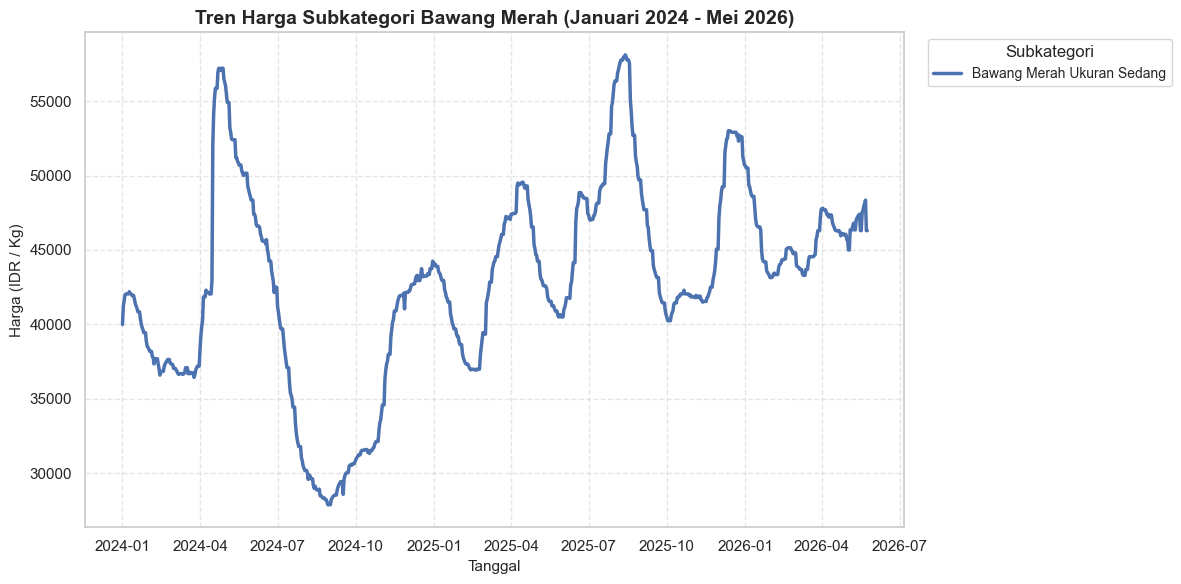

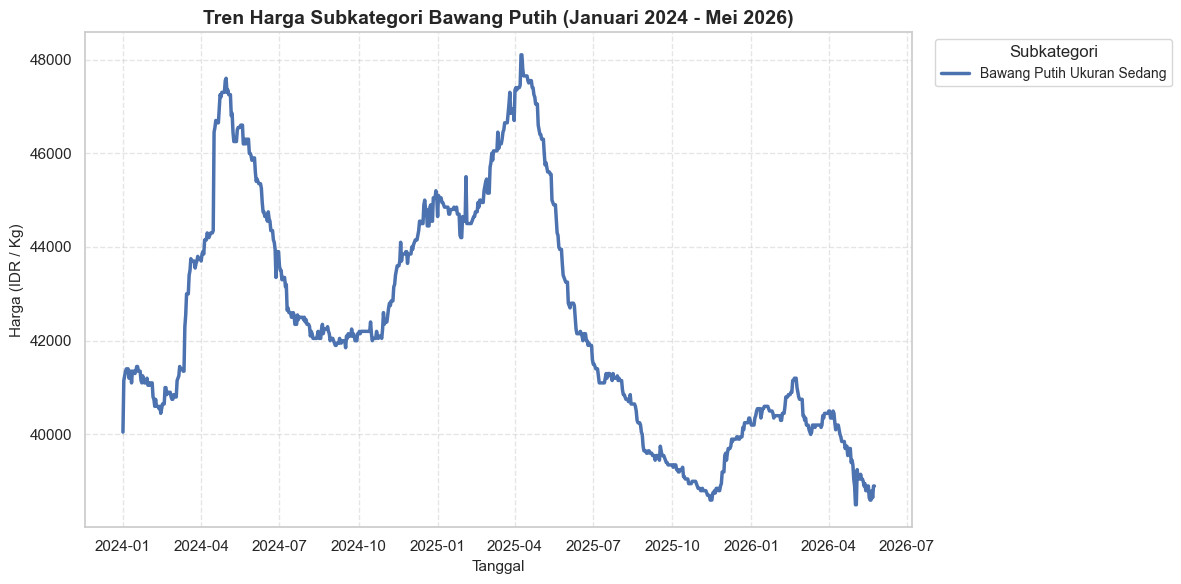

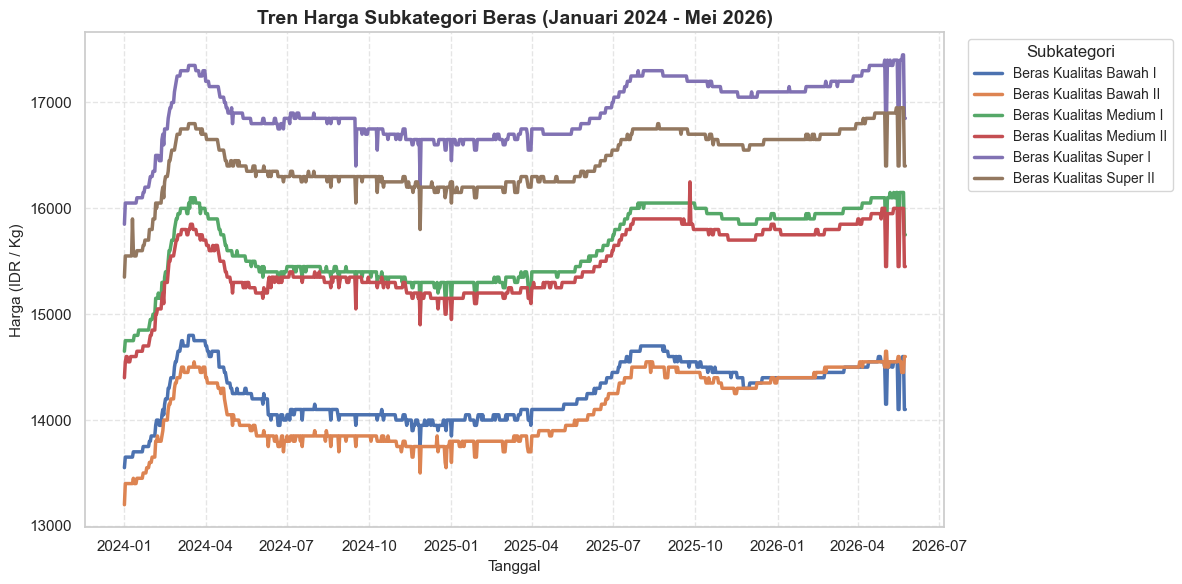

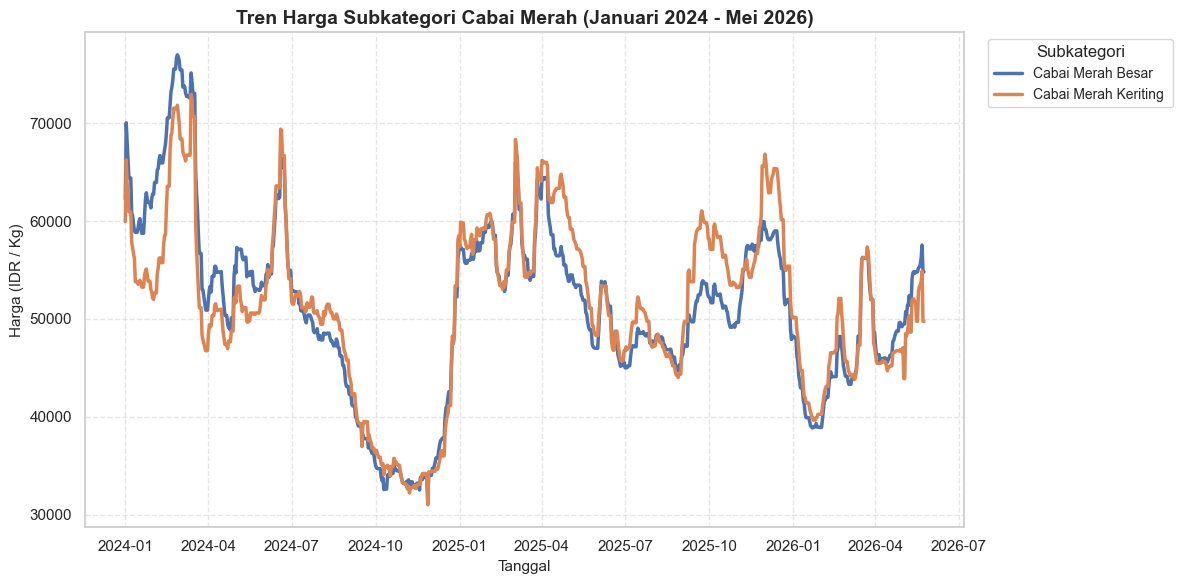

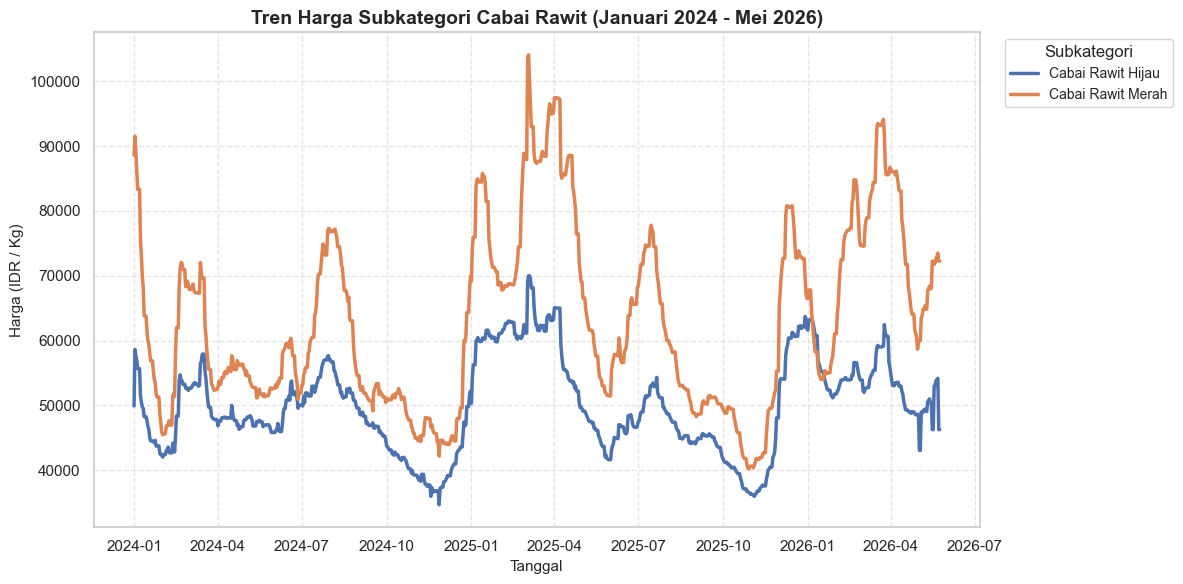

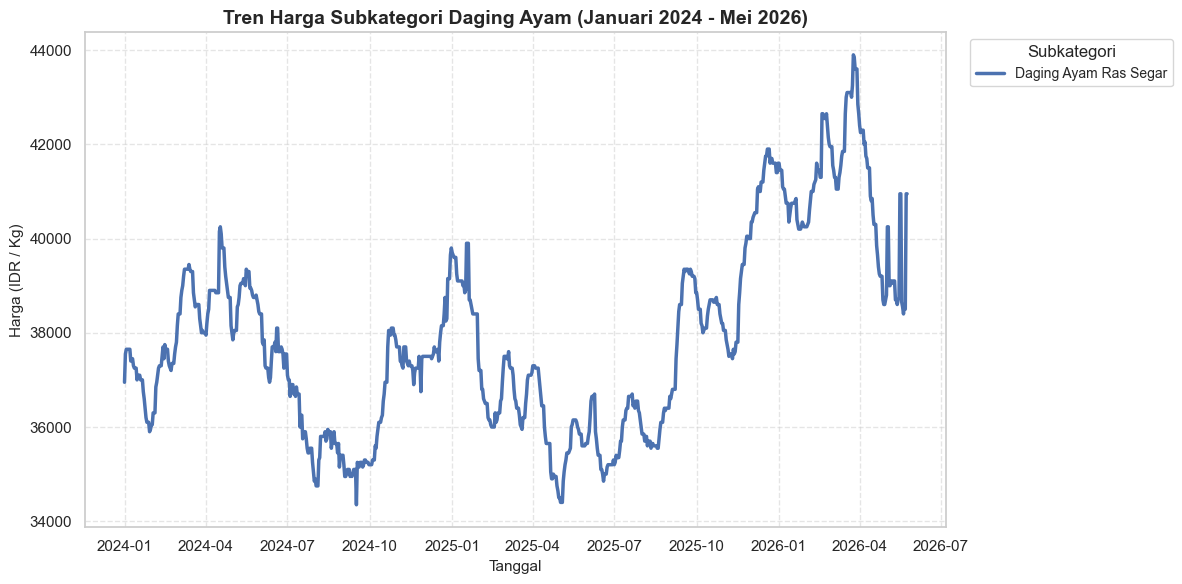

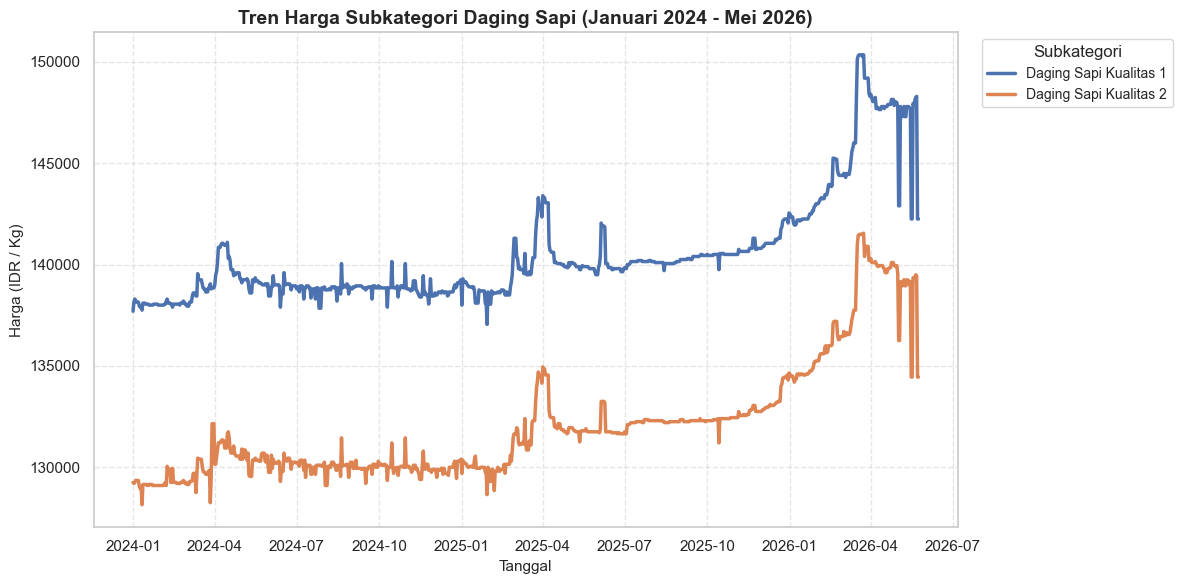

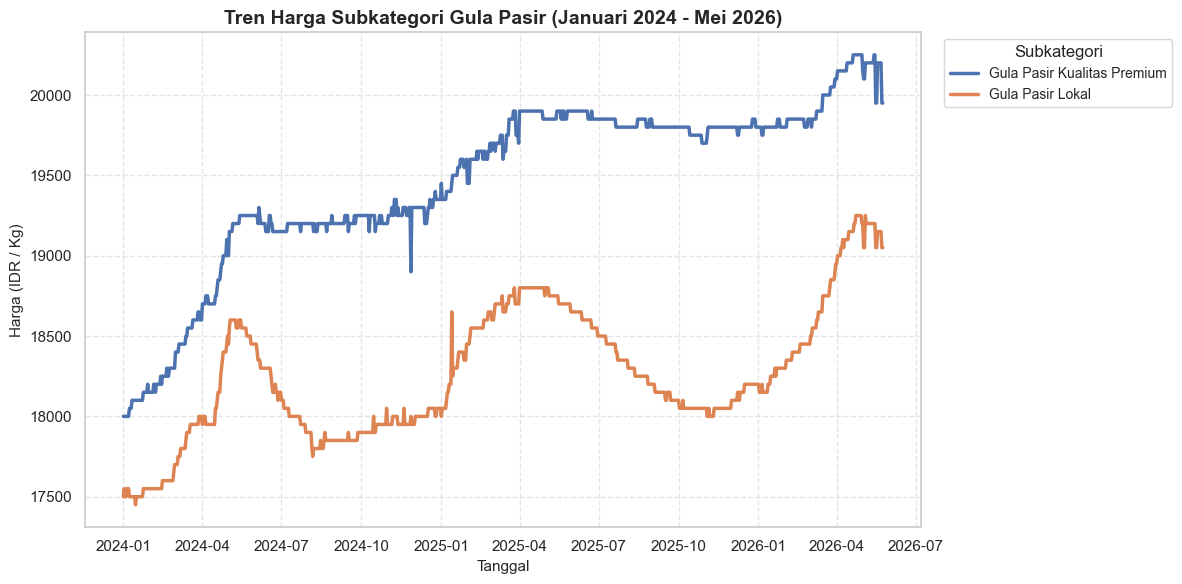

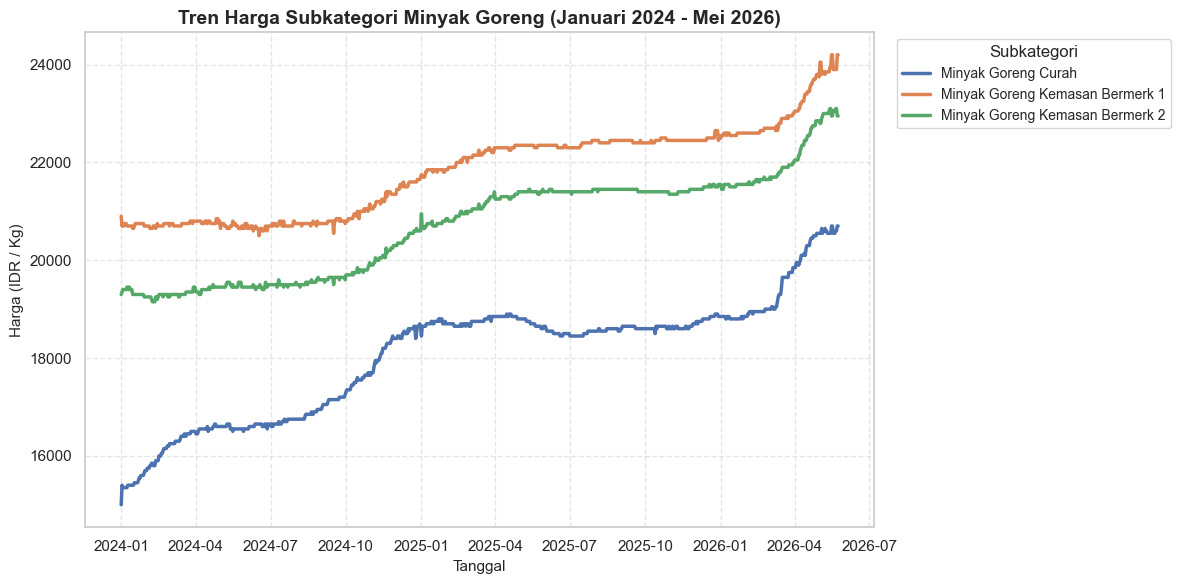

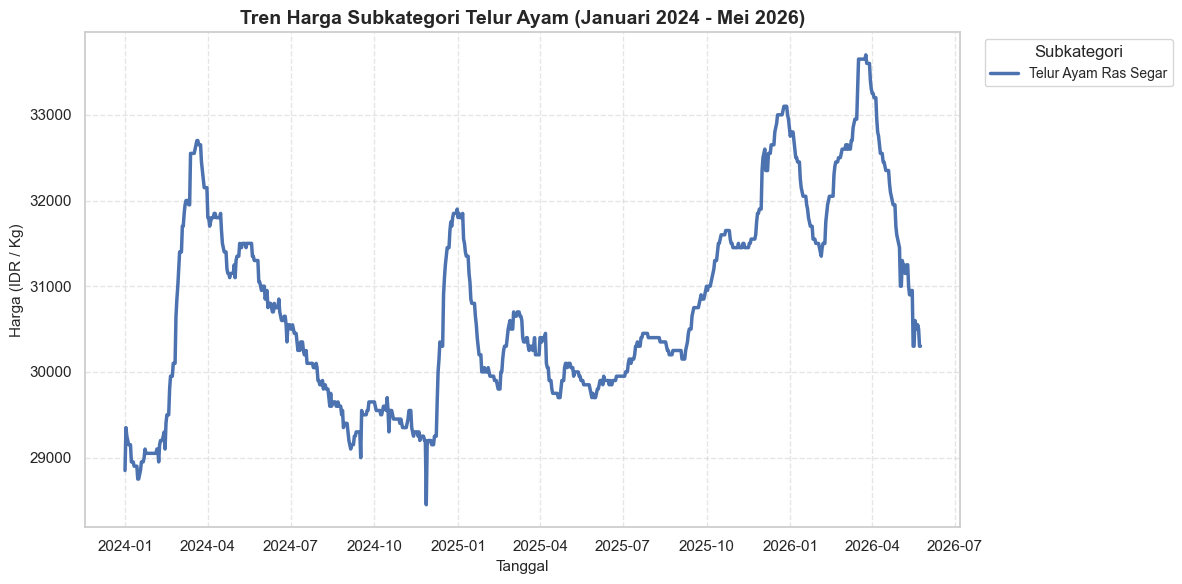

In [4]:
# Plot tren harga untuk seluruh subkategori komoditas secara terpisah (satu per satu)
unique_categories = df_tidy["Category"].unique()

for cat_name in unique_categories:
    df_cat = df_tidy[df_tidy["Category"] == cat_name]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_cat, x="Date", y="Price", hue="Subcategory", linewidth=2.5)
    
    plt.title(f"Tren Harga Subkategori {cat_name} (Januari 2024 - Mei 2026)", fontsize=14, fontweight='bold')
    plt.xlabel("Tanggal", fontsize=11)
    plt.ylabel("Harga (IDR / Kg)", fontsize=11)
    plt.legend(title="Subkategori", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

In [5]:
# Uji Dickey-Fuller Stasioneritas untuk Seluruh Subkategori
adf_results = []

for subcat_name in df_tidy["Subcategory"].unique():
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    # Imputasi sementara untuk uji ADF (jika ada nilai kosong)
    price_series = df_subcat["Price"].interpolate(method='linear').ffill().bfill()
    
    result = adfuller(price_series)
    adf_results.append({
        "Category": df_subcat["Category"].iloc[0] if not df_subcat.empty else "",
        "Subcategory": subcat_name,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Is Stationary": "Stasioner" if result[1] < 0.05 else "TIDAK Stasioner"
    })

df_adf_summary = pd.DataFrame(adf_results)
print("Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:")
df_adf_summary

Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:


,Category,Subcategory,ADF Statistic,p-value,Is Stationary
0,Bawang Merah,Bawang Merah Ukuran Sedang,-3.4297,0.0100,Stasioner
1,Bawang Putih,Bawang Putih Ukuran Sedang,-1.7349,0.4132,TIDAK Stasioner
2,Beras,Beras Kualitas Bawah I,-3.5541,0.0067,Stasioner
3,Beras,Beras Kualitas Bawah II,-2.6118,0.0906,TIDAK Stasioner
4,Beras,Beras Kualitas Medium I,-3.1120,0.0257,Stasioner
5,Beras,Beras Kualitas Medium II,-3.3318,0.0135,Stasioner
6,Beras,Beras Kualitas Super I,-3.8322,0.0026,Stasioner
7,Beras,Beras Kualitas Super II,-3.9669,0.0016,Stasioner
8,Cabai Merah,Cabai Merah Besar,-2.5208,0.1105,TIDAK Stasioner
9,Cabai Merah,Cabai Merah Keriting,-3.4356,0.0098,Stasioner


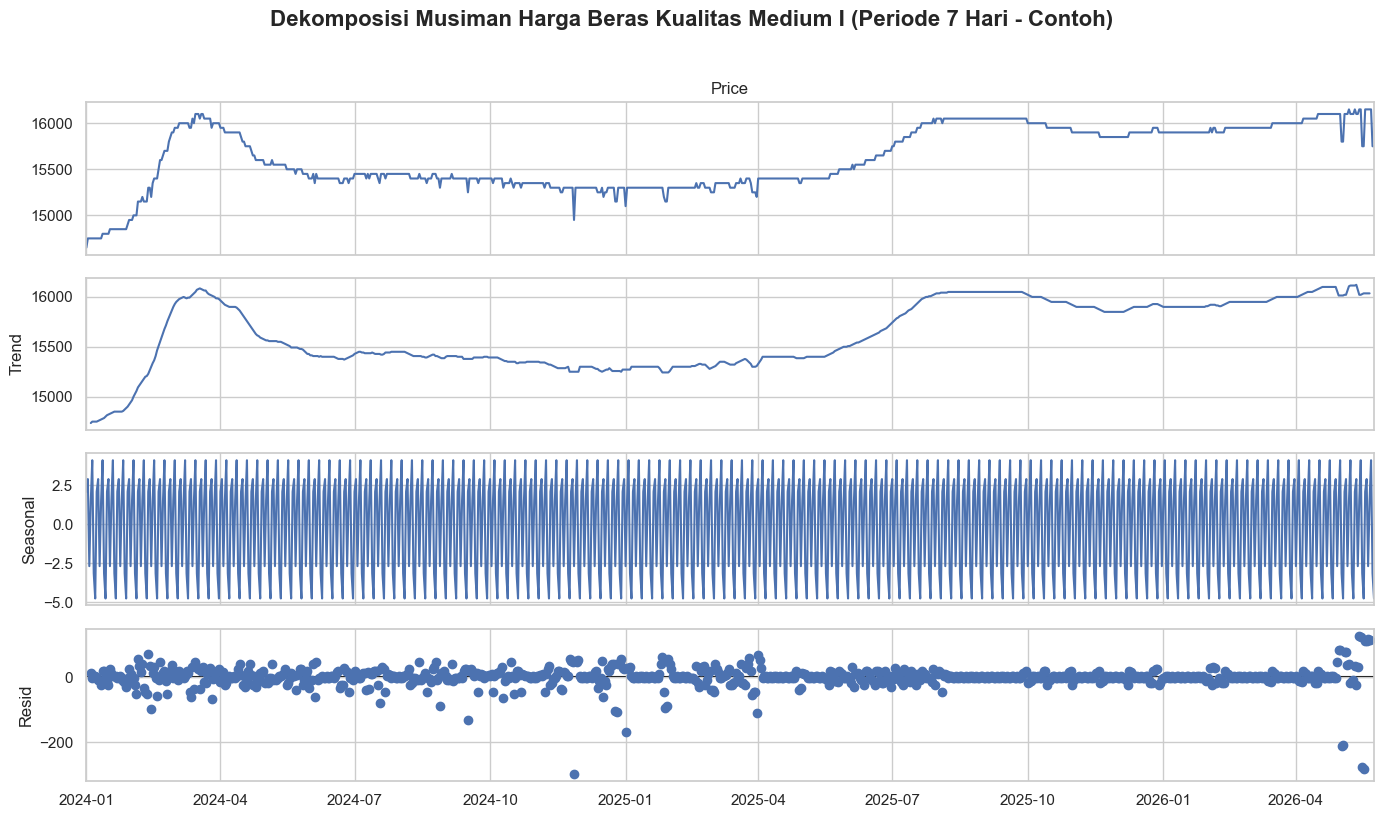

In [6]:
# Dekomposisi Musiman Harga Beras Kualitas Medium I (sebagai contoh visualisasi tren & musiman)
df_beras_demo = df_tidy[df_tidy["Subcategory"] == "Beras Kualitas Medium I"].copy()
df_beras_demo = df_beras_demo.set_index("Date").asfreq('D')
df_beras_demo["Price"] = df_beras_demo["Price"].interpolate(method='linear').ffill().bfill()

decomposition = seasonal_decompose(df_beras_demo["Price"], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Dekomposisi Musiman Harga Beras Kualitas Medium I (Periode 7 Hari - Contoh)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Modeling Functions
Sebelum melatih model K-Nearest Neighbors (KNN) pada ke-21 subkategori komoditas pangan, kita mempersiapkan fungsi preprocessing dan pembuatan model yang handal dan bebas kebocoran data (*data leakage*):
1. **Log-Transformation**: Mengurangi ketimpangan varians (volatilitas tinggi) serta mencegah prediksi harga negatif di backend dengan melakukan transformasi logaritma natural (`np.log1p`) pada harga pangan sebelum fitting/scaling.
2. **Pembuatan Fitur Temporal & Lag**: Menghitung hari dalam seminggu, tanggal, bulan, tahun, akhir pekan, serta lag harga (t-1, t-2, t-7) dan statistik bergulir (rata-rata dan standar deviasi bergulir 7 hari dari lag_1 untuk mencegah leakage).
3. **Skalasi Fitur**: Karena KNN mengandalkan perhitungan jarak geometris (Euclidean/Manhattan), penskalaan fitur sangat wajib. MinMaxScaler dilatih (*fit*) hanya pada training set (80% data awal), lalu digunakan untuk mentransformasi training set dan test set secara terpisah.
4. **Hyperparameter Tuning Otomatis**: Menjalankan Grid Search (`GridSearchCV`) dengan pembagian validasi khusus deret waktu (`TimeSeriesSplit` dengan 5 splits) untuk mencari kombinasi parameter terbaik (`n_neighbors`, `weights`, `metric`) secara dinamis.

In [7]:
def preprocess_series(df_series):
    df = df_series.copy()
    df = df.asfreq('D')
    df['Price'] = df['Price'].interpolate(method='linear').ffill().bfill()
    df['Price_log'] = np.log1p(df['Price'])

    # Fitur Kalender
    df['day_of_week'] = df.index.dayofweek
    df['day_of_month'] = df.index.day
    df['day_of_year'] = df.index.dayofyear
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

    # Fitur Lag (berdasarkan log price)
    df['lag_1'] = df['Price_log'].shift(1)
    df['lag_2'] = df['Price_log'].shift(2)
    df['lag_7'] = df['Price_log'].shift(7)

    # Fitur Rolling (berdasarkan lag_1 untuk mencegah leakage)
    df['rolling_mean_7'] = df['lag_1'].rolling(window=7).mean()
    df['rolling_std_7'] = df['lag_1'].rolling(window=7).std()

    df = df.dropna()
    return df

def tune_and_train_knn(X_train, y_train):
    # TimeSeriesSplit untuk menjaga integritas temporal saat tuning
    tscv = TimeSeriesSplit(n_splits=5)
    
    param_grid = {
        'n_neighbors': list(range(3, 16)),
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    
    grid = GridSearchCV(
        KNeighborsRegressor(),
        param_grid=param_grid,
        cv=tscv,
        scoring='neg_mean_squared_error',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_

def evaluate_predictions(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE (%)": mape, "R2 Score": r2}

In [8]:
# Eksekusi Loop Pelatihan Model KNN untuk Seluruh Subkategori
all_metrics = []
predictions_dict = {}
best_params_dict = {}

subcategories = df_tidy["Subcategory"].unique()
features = ['day_of_week', 'day_of_month', 'day_of_year', 'month', 'is_weekend',
            'lag_1', 'lag_2', 'lag_7', 'rolling_mean_7', 'rolling_std_7']

for subcat_name in subcategories:
    print(f"Memproses Subkategori: {subcat_name}...")
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    if df_subcat.empty:
        print(f"  Peringatan: Data untuk {subcat_name} tidak ditemukan.")
        continue
        
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    
    # 1. Preprocess (dengan Log-transformation)
    df_prep = preprocess_series(df_subcat)
    
    # 2. Split
    split_idx = int(len(df_prep) * 0.8)
    df_train = df_prep.iloc[:split_idx].copy()
    df_test = df_prep.iloc[split_idx:].copy()
    
    X_train, y_train = df_train[features], df_train['Price_log']
    X_test, y_test = df_test[features], df_test['Price_log']
    
    # 3. Scale (MinMaxScaler pada log price)
    scaler_X = MinMaxScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled = scaler_X.transform(X_test)
    
    # 4. Tune & Train
    best_model, best_params = tune_and_train_knn(X_train_scaled, y_train)
    best_params_dict[subcat_name] = best_params
    
    # 5. Predict
    y_pred_log = best_model.predict(X_test_scaled)
    # Konversi balik dari log scale ke Rupiah asli
    y_pred_orig = np.expm1(y_pred_log)
    
    # Ambil data aktual yang sesuai
    df_test_eval = df_test.copy()
    df_test_eval['KNN_Prediction'] = y_pred_orig
    predictions_dict[subcat_name] = df_test_eval
    
    # 6. Evaluate
    metrics = evaluate_predictions(df_test_eval['Price'], df_test_eval['KNN_Prediction'])
    
    all_metrics.append({
        "Subcategory": subcat_name,
        "MAE": round(metrics["MAE"], 4),
        "RMSE": round(metrics["RMSE"], 4),
        "MAPE (%)": round(metrics["MAPE (%)"], 4),
        "R2 Score": round(metrics["R2 Score"], 4)
    })
    print(f"  Best params: {best_params} | MAE: {metrics['MAE']:.2f} | RMSE: {metrics['RMSE']:.2f} | MAPE: {metrics['MAPE (%)']:.4f}% | R2: {metrics['R2 Score']:.4f}")

df_all_metrics = pd.DataFrame(all_metrics)
print("\nProses modeling selesai untuk seluruh subkategori.")

Memproses Subkategori: Bawang Merah Ukuran Sedang...


  Best params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'} | MAE: 1616.77 | RMSE: 2295.25 | MAPE: 3.3118% | R2: 0.3539
Memproses Subkategori: Bawang Putih Ukuran Sedang...
  Best params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'distance'} | MAE: 750.71 | RMSE: 863.49 | MAPE: 1.8860% | R2: -1.0043
Memproses Subkategori: Beras Kualitas Bawah I...


  Best params: {'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'} | MAE: 70.99 | RMSE: 107.30 | MAPE: 0.4935% | R2: -0.4229
Memproses Subkategori: Beras Kualitas Bawah II...
  Best params: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'} | MAE: 44.35 | RMSE: 55.52 | MAPE: 0.3060% | R2: 0.5168
Memproses Subkategori: Beras Kualitas Medium I...


  Best params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'} | MAE: 55.31 | RMSE: 75.80 | MAPE: 0.3460% | R2: 0.3004
Memproses Subkategori: Beras Kualitas Medium II...
  Best params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'} | MAE: 84.23 | RMSE: 116.68 | MAPE: 0.5318% | R2: -0.1561
Memproses Subkategori: Beras Kualitas Super I...


  Best params: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'} | MAE: 66.09 | RMSE: 103.28 | MAPE: 0.3851% | R2: 0.2937
Memproses Subkategori: Beras Kualitas Super II...
  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} | MAE: 72.40 | RMSE: 110.03 | MAPE: 0.4319% | R2: 0.1502
Memproses Subkategori: Cabai Merah Besar...


...

  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} | MAE: 1787.65 | RMSE: 2087.23 | MAPE: 4.2892% | R2: -1.7911
Memproses Subkategori: Daging Sapi Kualitas 1...
  Best params: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'} | MAE: 2791.04 | RMSE: 3748.52 | MAPE: 1.8941% | R2: -0.7050
Memproses Subkategori: Daging Sapi Kualitas 2...


  Best params: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'} | MAE: 3000.14 | RMSE: 3869.71 | MAPE: 2.1592% | R2: -1.1412
Memproses Subkategori: Gula Pasir Kualitas Premium...
  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} | MAE: 147.08 | RMSE: 188.96 | MAPE: 0.7326% | R2: -0.2353
Memproses Subkategori: Gula Pasir Lokal...


  Best params: {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'} | MAE: 171.14 | RMSE: 223.09 | MAPE: 0.9069% | R2: 0.6928
Memproses Subkategori: Minyak Goreng Curah...
  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} | MAE: 690.94 | RMSE: 948.80 | MAPE: 3.4423% | R2: -0.8137
Memproses Subkategori: Minyak Goreng Kemasan Bermerk 1...


  Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'distance'} | MAE: 600.50 | RMSE: 780.03 | MAPE: 2.5710% | R2: -1.2847
Memproses Subkategori: Minyak Goreng Kemasan Bermerk 2...
  Best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'} | MAE: 585.34 | RMSE: 800.75 | MAPE: 2.6075% | R2: -1.1393
Memproses Subkategori: Telur Ayam Ras Segar...


  Best params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'} | MAE: 531.47 | RMSE: 697.44 | MAPE: 1.6209% | R2: 0.2571

Proses modeling selesai untuk seluruh subkategori.


## 4. Model Evaluation & Comparison
Bagian ini menyajikan performa model **K-Nearest Neighbors (KNN)** untuk ke-21 subkategori komoditas pangan berdasarkan metrik statistik (MAE, RMSE, MAPE, dan R2 Score) pada data pengujian.

In [9]:
# Menampilkan Ringkasan Evaluasi Seluruh Subkategori menggunakan KNN
df_summary = df_all_metrics.set_index("Subcategory")
pd.set_option('display.max_columns', None)
df_summary

,MAE,RMSE,MAPE (%),R2 Score
Subcategory,,,,
Bawang Merah Ukuran Sedang,1616.7710,2295.2543,3.3118,0.3539
Bawang Putih Ukuran Sedang,750.7146,863.4865,1.8860,-1.0043
Beras Kualitas Bawah I,70.9935,107.2959,0.4935,-0.4229
Beras Kualitas Bawah II,44.3478,55.5177,0.3060,0.5168
Beras Kualitas Medium I,55.3064,75.8006,0.3460,0.3004
Beras Kualitas Medium II,84.2285,116.6817,0.5318,-0.1561
Beras Kualitas Super I,66.0921,103.2839,0.3851,0.2937
Beras Kualitas Super II,72.3961,110.0336,0.4319,0.1502
Cabai Merah Besar,3988.4990,5253.5000,8.9080,0.1899


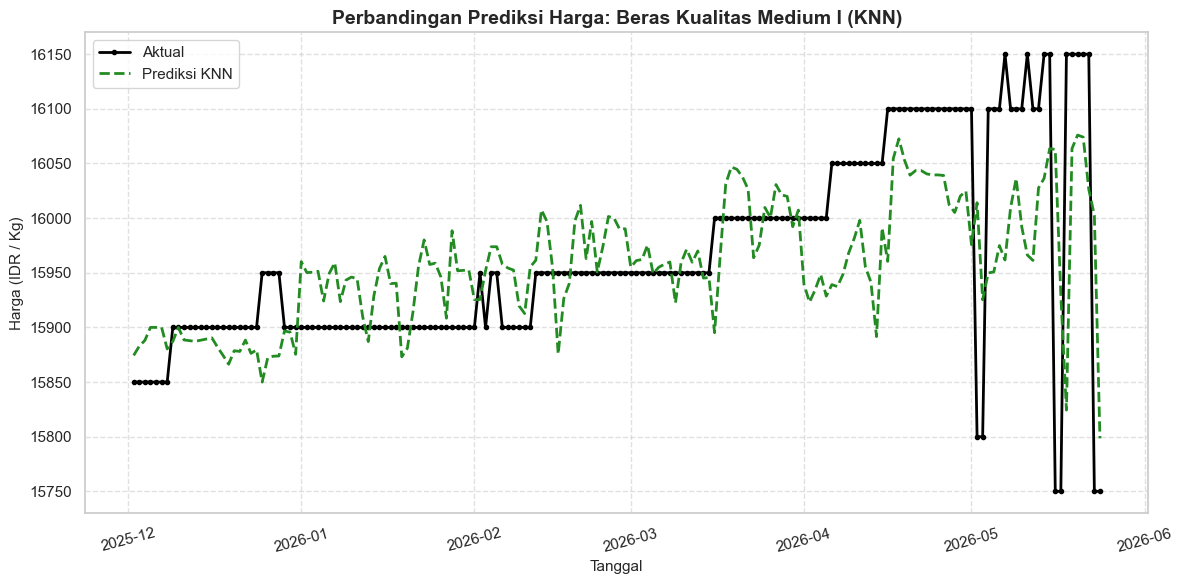

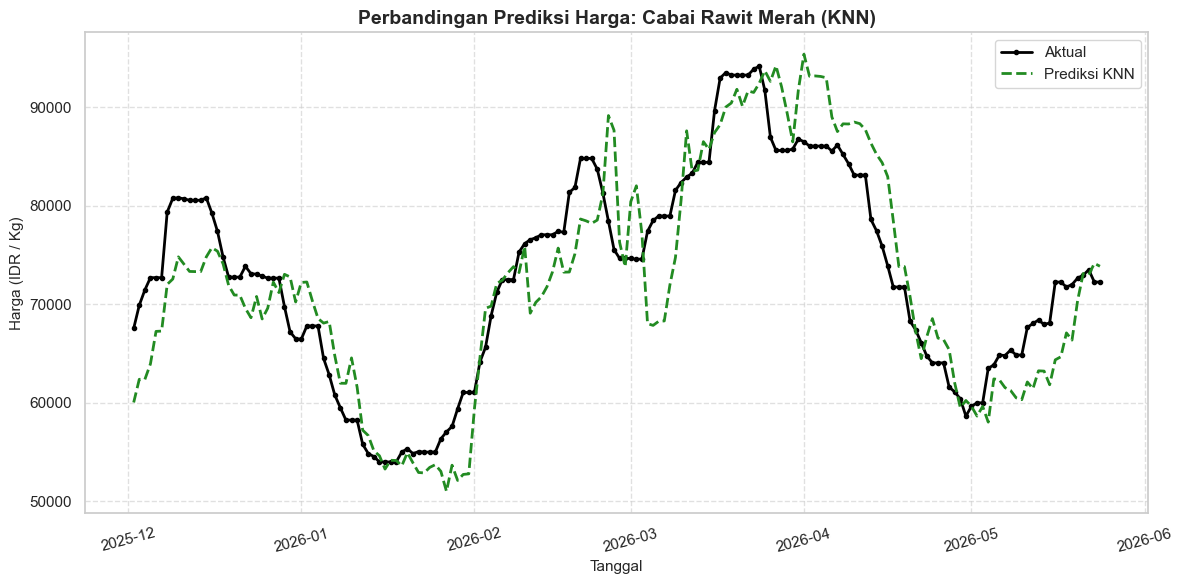

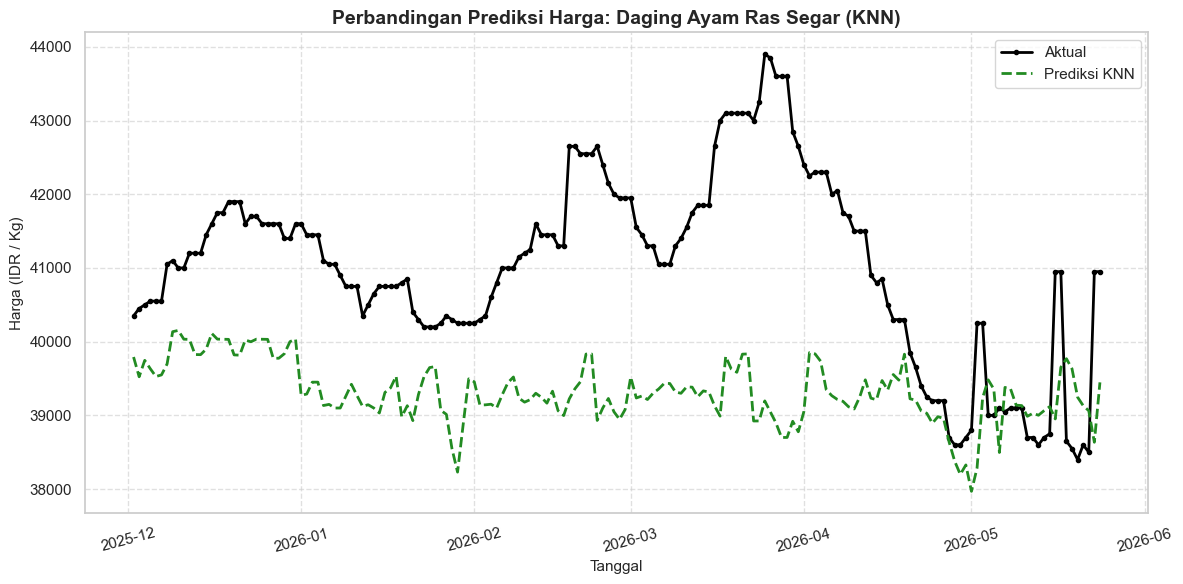

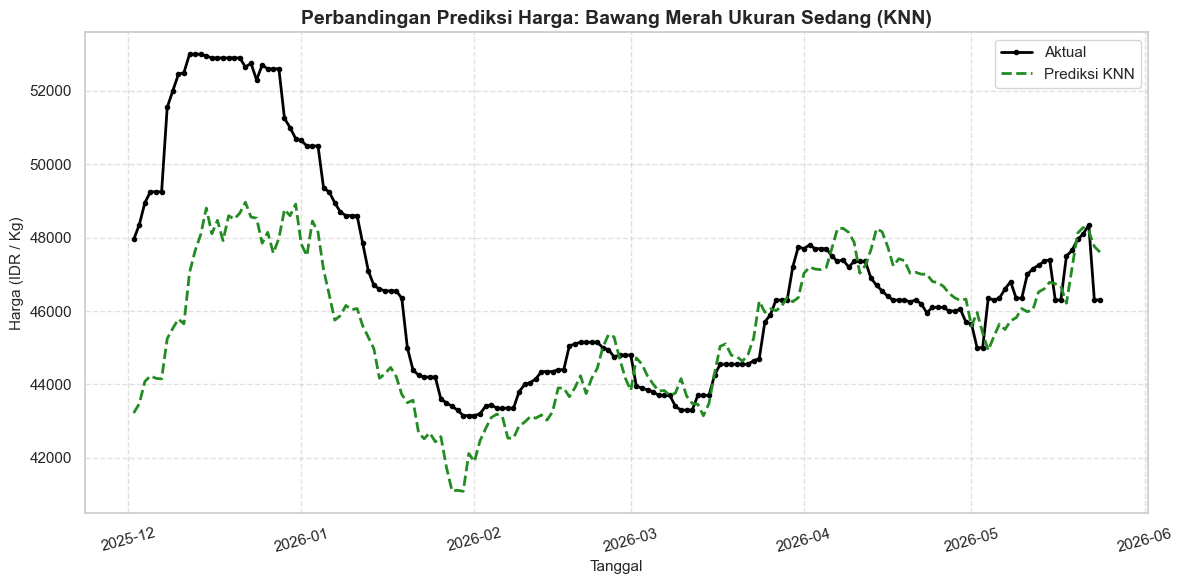

In [10]:
# Visualisasi Kurva Prediksi vs Aktual untuk 4 Subkategori Kunci
key_commodities = ["Beras Kualitas Medium I", "Cabai Rawit Merah", "Daging Ayam Ras Segar", "Bawang Merah Ukuran Sedang"]

for cat_name in key_commodities:
    if cat_name in predictions_dict:
        df_pred = predictions_dict[cat_name]
        
        plt.figure(figsize=(12, 6))
        plt.plot(df_pred.index, df_pred["Price"], label="Aktual", color="black", linewidth=2, marker='o', markersize=3)
        plt.plot(df_pred.index, df_pred["KNN_Prediction"], label="Prediksi KNN", color="forestgreen", linestyle="--", linewidth=2)
        
        plt.title(f"Perbandingan Prediksi Harga: {cat_name} (KNN)", fontsize=14, fontweight='bold')
        plt.xlabel("Tanggal", fontsize=11)
        plt.ylabel("Harga (IDR / Kg)", fontsize=11)
        plt.legend(fontsize=11)
        plt.xticks(rotation=15)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Data untuk {cat_name} tidak ditemukan")

## Kesimpulan Analisis Eksplorasi KNN
Berdasarkan hasil pemodelan deret waktu menggunakan K-Nearest Neighbors (KNN) pada 21 subkategori komoditas pangan nasional:

1. **Kemampuan Menangkap Pola Lokal**:
   - Model KNN bekerja cukup baik pada komoditas yang memiliki pergerakan harga stabil dan berulang. Karena KNN didasarkan pada kesamaan jarak (distance-based similarity), ia mampu mengenali "kondisi pasar serupa" dari masa lalu untuk menetapkan harga.

2. **Peran Log-Transformation & MinMaxScaler**:
   - Log-transformation menstabilkan fluktuasi harga yang sangat dinamis pada komoditas volatil (seperti Cabai) dan menghindari prediksi negatif. Penskalaan fitur (MinMaxScaler) secara mutlak diperlukan karena fitur kalender dan fitur lag berada pada besaran range yang berbeda; tanpa penskalaan, fitur dengan range besar akan mendominasi perhitungan jarak.

3. **Efek Hyperparameter Tuning**:
   - Tuning otomatis menggunakan `GridSearchCV` dengan `TimeSeriesSplit` menjamin parameter jumlah tetangga (`n_neighbors`), bobot (`uniform` vs `distance`), dan metrik jarak (`euclidean` vs `manhattan`) terpilih secara optimal tanpa memicu terjadinya data leakage temporal.